<a href="https://colab.research.google.com/github/mahim83/Deep-Learning-Assignments-certificates/blob/main/Assignment4_Backpropagation_Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving abalone (2).zip to abalone (2) (2).zip
Dataset Shape: (4177, 9)
  Sex  Length  Diameter  Height  WholeWeight  ShuckedWeight  VisceraWeight  \
0   M   0.455     0.365   0.095       0.5140         0.2245         0.1010   
1   M   0.350     0.265   0.090       0.2255         0.0995         0.0485   
2   F   0.530     0.420   0.135       0.6770         0.2565         0.1415   
3   M   0.440     0.365   0.125       0.5160         0.2155         0.1140   
4   I   0.330     0.255   0.080       0.2050         0.0895         0.0395   

   ShellWeight  Rings  
0        0.150     15  
1        0.070      7  
2        0.210      9  
3        0.155     10  
4        0.055      7  
Epoch: 0 Loss: 109.22905667338057
Epoch: 100 Loss: 6.487721297721184
Epoch: 200 Loss: 6.1783571203089345
Epoch: 300 Loss: 5.931326035918977
Epoch: 400 Loss: 5.727357028611369
Epoch: 500 Loss: 5.558870159080861
Epoch: 600 Loss: 5.420623995500634
Epoch: 700 Loss: 5.308280162587451
Epoch: 800 Loss: 5.217884143910915
E

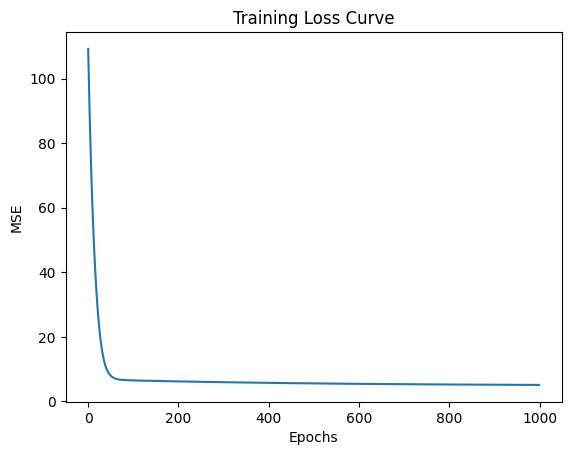

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zipfile
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error


from google.colab import files
uploaded = files.upload()

zip_file_name = list(uploaded.keys())[0]


with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall('.')

data = pd.read_csv("abalone.data", header=None)

data.columns = [
    "Sex","Length","Diameter","Height","WholeWeight",
    "ShuckedWeight","VisceraWeight","ShellWeight","Rings"
]

print("Dataset Shape:", data.shape)
print(data.head())


data = pd.get_dummies(data, columns=["Sex"])

X = data.drop("Rings", axis=1).values
y = data["Rings"].values

y = y.reshape(-1,1)

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

input_size = X_train.shape[1]
hidden_size = 10
output_size = 1

np.random.seed(42)

W1 = np.random.randn(input_size, hidden_size) * 0.01
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size) * 0.01
b2 = np.zeros((1, output_size))

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
    return a * (1 - a)

def forward(X):

    z1 = np.dot(X, W1) + b1
    a1 = sigmoid(z1)

    z2 = np.dot(a1, W2) + b2
    y_pred = z2

    return z1, a1, z2, y_pred

def compute_loss(y, y_pred):

    return np.mean((y - y_pred)**2)

learning_rate = 0.01
epochs = 1000

losses = []

for i in range(epochs):

    z1, a1, z2, y_pred = forward(X_train)

    loss = compute_loss(y_train, y_pred)
    losses.append(loss)

    dz2 = (y_pred - y_train)

    dW2 = np.dot(a1.T, dz2) / X_train.shape[0]
    db2 = np.sum(dz2, axis=0, keepdims=True) / X_train.shape[0]

    dz1 = np.dot(dz2, W2.T) * sigmoid_derivative(a1)

    dW1 = np.dot(X_train.T, dz1) / X_train.shape[0]
    db1 = np.sum(dz1, axis=0, keepdims=True) / X_train.shape[0]

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    if i % 100 == 0:
        print("Epoch:", i, "Loss:", loss)


_, _, _, y_pred_test = forward(X_test)



mse = mean_squared_error(y_test, y_pred_test)

print("\nTest MSE:", mse)

plt.plot(losses)
plt.title("Training Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.show()